In [3]:
import os
import glob
import pandas as pd

base_dir = "/Users/ppxinyi/Documents/Assembly_review/30xL1-L3"  
tools = ["Flye","Wtdbg2","Raven","Canu","Shasta","Nextdenover"]

acc_thr = 0.7
bias_thr = 5000

def infer_level(fname_lower: str):
    if "l1" in fname_lower:
        return "l1"
    if "l2" in fname_lower:
        return "l2"
    if "l3" in fname_lower:
        return "l3"
    return None

def pick_files(tool_dir: str):
    """
    Return dicts:
      acc_files[level] = filepath  (filename contains 'accuracy')
      bias_files[level] = filepath (filename contains 'bias')
    case-insensitive.
    """
    acc_files = {}
    bias_files = {}

    for fp in glob.glob(os.path.join(tool_dir, "*.csv")):
        fn = os.path.basename(fp).lower()

        lv = infer_level(fn)
        if lv is None:
            continue

        if "accuracy" in fn:
            acc_files.setdefault(lv, fp)

        if "bias" in fn:
            bias_files.setdefault(lv, fp)

    return acc_files, bias_files

rows = []

for tool in tools:
    tool_dir = os.path.join(base_dir, tool)

    acc_files, bias_files = pick_files(tool_dir)

  
    for lv in ["l1","l2","l3"]:
        if lv not in acc_files:
            print(f"[WARN] {tool} missing ACCURACY file for {lv} in {tool_dir}")
        if lv not in bias_files:
            print(f"[WARN] {tool} missing BIAS file for {lv} in {tool_dir}")

    for lv in ["l1","l2","l3"]:
        if lv not in acc_files or lv not in bias_files:
            continue

        acc_fp = acc_files[lv]
        bias_fp = bias_files[lv]

        acc = pd.read_csv(acc_fp)
        bias = pd.read_csv(bias_fp)

        # 只取需要的列，避免重名和加速
        need_acc = {"event_id", "ordered_best_overlap_pct"}
        need_bias = {"event_id", "abs_bias_bp"}

        if not need_acc.issubset(acc.columns):
            raise ValueError(f"{tool} {lv} accuracy file missing columns {need_acc - set(acc.columns)}: {acc_fp}")
        if not need_bias.issubset(bias.columns):
            raise ValueError(f"{tool} {lv} bias file missing columns {need_bias - set(bias.columns)}: {bias_fp}")

        acc = acc[["event_id", "ordered_best_overlap_pct"]].copy()
        bias = bias[["event_id", "abs_bias_bp"]].copy()

        # merge
        merged = acc.merge(bias, on="event_id", how="inner")

        passed = merged.loc[
            (merged["ordered_best_overlap_pct"] >= acc_thr) &
            (merged["abs_bias_bp"] < bias_thr),
            "event_id"
        ].dropna().unique()

        for ev in passed:
            rows.append({"event_id": ev, "level": lv, "tool": tool, "pass": True})

upset_long = pd.DataFrame(rows).drop_duplicates()
upset_long.to_csv("/Users/ppxinyi/Documents/Assembly_review/30xL1-L3/upset_input_long2.csv", index=False)

print("Done. Passing rows:", len(upset_long))

[WARN] Canu missing ACCURACY file for l1 in /Users/ppxinyi/Documents/Assembly_review/30xL1-L3/Canu
[WARN] Canu missing BIAS file for l1 in /Users/ppxinyi/Documents/Assembly_review/30xL1-L3/Canu
[WARN] Canu missing ACCURACY file for l2 in /Users/ppxinyi/Documents/Assembly_review/30xL1-L3/Canu
[WARN] Canu missing BIAS file for l2 in /Users/ppxinyi/Documents/Assembly_review/30xL1-L3/Canu
[WARN] Canu missing ACCURACY file for l3 in /Users/ppxinyi/Documents/Assembly_review/30xL1-L3/Canu
[WARN] Canu missing BIAS file for l3 in /Users/ppxinyi/Documents/Assembly_review/30xL1-L3/Canu
Done. Passing rows: 169


/var/folders/hk/lqmfb44d2vg7sz2f89kx3bk40000gn/T/ipykernel_18892/4256601930.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


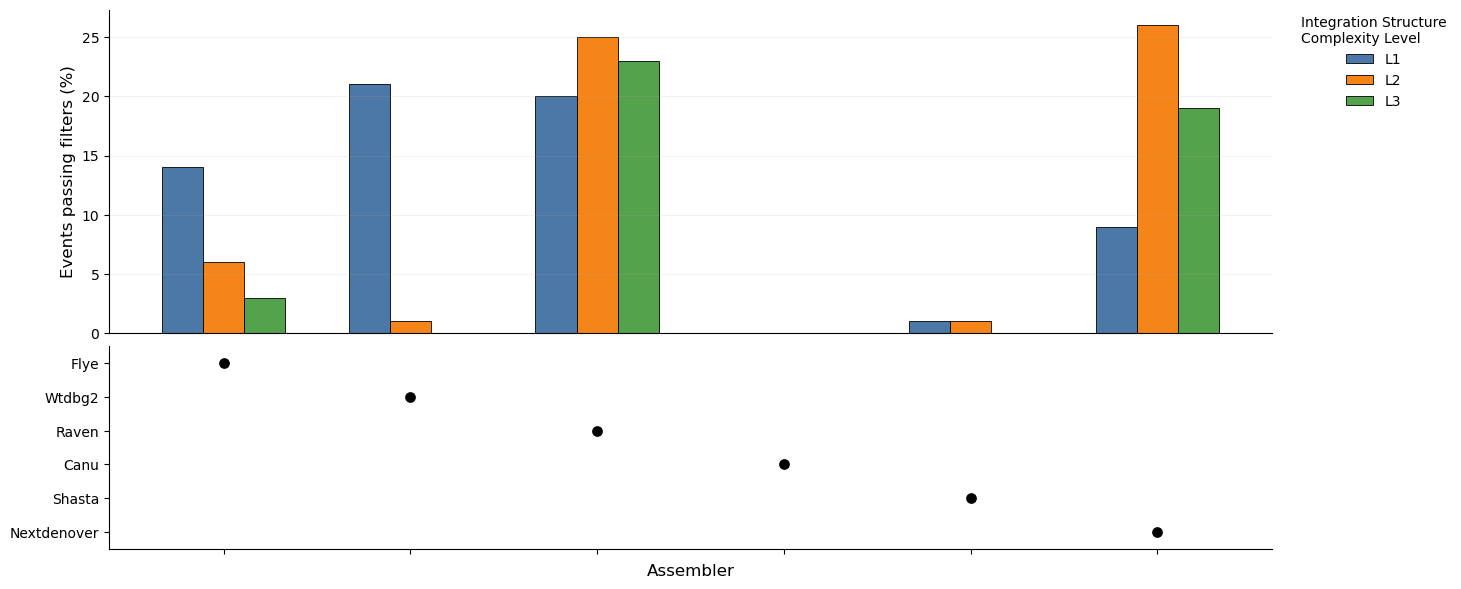

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def upset_style_per_tool_counts(df_long,
                                tools,
                                level_order=("l1","l2","l3"),
                                figsize=(10, 6)):

    d = df_long.copy()
    d["tool"] = d["tool"].astype(str).str.strip()
    d["level"] = d["level"].astype(str).str.lower().str.strip()

    if "pass" in d.columns:
        d = d[d["pass"].astype(bool)]

    d = d[d["tool"].isin(tools)]

    counts = (d.drop_duplicates(["event_id","level","tool"])
                .groupby(["tool","level"])
                .size()
                .unstack(fill_value=0)
                .reindex(index=tools, columns=list(level_order), fill_value=0))

    # 
    nature_colors = {
        "l1": "#4C78A8",  # blue
        "l2": "#F58518",  # orange
        "l3": "#54A24B",  # green
    }

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 1, height_ratios=[3.2, 2.0], hspace=0.05)
    ax_bar = fig.add_subplot(gs[0])
    ax_mat = fig.add_subplot(gs[1], sharex=ax_bar)

    x = np.arange(len(tools))
    bar_w = 0.22
    offsets = np.linspace(-bar_w, bar_w, num=len(level_order))

    #barplot above
    for i, lv in enumerate(level_order):
        ax_bar.bar(
            x + offsets[i],
            counts[lv].values,
            width=bar_w,
            color=nature_colors[lv],
            edgecolor="black",
            linewidth=0.6,
            label=lv.upper()
        )

    ax_bar.set_ylabel("Events passing filters (%)", fontsize=12)
    # ax_bar.legend(title="Integration Structure Complexity Level", frameon=False)
    ax_bar.legend(
    title="Integration Structure\nComplexity Level",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
    )
    ax_bar.spines["top"].set_visible(False)
    ax_bar.spines["right"].set_visible(False)
    ax_bar.grid(axis="y", alpha=0.15)
    ax_bar.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

    #dot part black
    ax_mat.set_ylim(-0.5, len(tools) - 0.5)
    ax_mat.set_yticks(np.arange(len(tools)))
    ax_mat.set_yticklabels(tools)
    ax_mat.invert_yaxis()
    ax_mat.set_xlabel("Assembler", fontsize=12)

    for i, tool in enumerate(tools):
        y = tools.index(tool)
        ax_mat.scatter(i, y, s=45, color="black")

    ax_mat.spines["top"].set_visible(False)
    ax_mat.spines["right"].set_visible(False)
    ax_mat.set_xticks(x)
    ax_mat.set_xticklabels([""] * len(x))

    plt.tight_layout()
    return fig, (ax_bar, ax_mat), counts


# 
tools = ["Flye","Wtdbg2","Raven","Canu","Shasta","Nextdenover"]
df_long = pd.read_csv("/Users/ppxinyi/Documents/Assembly_review/30xL1-L3/upset_input_long2.csv")

fig, axes, counts = upset_style_per_tool_counts(df_long, tools, figsize=(15,7))
plt.savefig("/Users/ppxinyi/Documents/Assembly_review/30xL1-L3/main_figure/pass_plot75000.pdf")
plt.show()
